# In this Notebook  we demonstrate how the 4-qubit block reduction discussed in the notebook "Block_reduction_4_qubits" can be used to reduce the size of the brick wall random peaked quantum circuit

Here we cut the first layer of the circuit. Cutting the last layer of the circuit can be done in the same way.

After cutting 1-st layer, one may cut second, third etc layers.

### Uploading librarries

In [287]:
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display

import numpy as np
import random
import copy
import time

# SciPy minimizer routine
from scipy.optimize import minimize

PI = np.pi

### Definig functions that create a single brick in the brick wall ciruit, create peaked circuits, find 4-qubit block and 4-qubit reduced blocks etc

In [3]:
#Creates a single "brick" block and add it to an existing circuit
def add_double_cz_block(qc, params, qubits_list):
    qc.u(params[0], params[1], params[2], qubits_list[0])
    qc.u(params[3], params[4], params[5], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[6], params[7], params[8], qubits_list[0])
    qc.u(params[9], params[10], params[11], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[12], params[13], params[14], qubits_list[0])
    qc.u(params[15], params[16], params[17], qubits_list[1])
    return qc

#Creates a single inverted "brick" block and add it to an existing circuit
def add_double_inverse_cz_block(qc, params, qubits_list):
    pp = params
    qc.u(-pp[12], -pp[14], -pp[13], qubits_list[0])
    qc.u(-pp[15], -pp[17], -pp[16], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(-pp[6], -pp[8], -pp[7], qubits_list[0])
    qc.u(-pp[9], -pp[11], -pp[10], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(-pp[0], -pp[2], -pp[1], qubits_list[0])
    qc.u(-pp[3], -pp[5], -pp[4], qubits_list[1])
    return qc

#Creates a single "brick" block operator
def double_cz_op(par):
    q_2 = qiskit.QuantumCircuit(2)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.cz(0,1)
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    op = Operator(q_2)
    return op

#Calculate difference between two "brick" blocks
def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el

# auxialiry function for optimization
def estim_func(params, init_circ):
    test_circ = double_cz_op(params)
    est = double_q_diff(init_circ, test_circ)
    return est

#Take an intial "brick" block and find another "brick" block that performs alsmost the same function as initial block
def find_alt_params(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = double_cz_op(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(18) * 2 * PI
        res = minimize(
                    estim_func,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break

    return min_dev_par


In [341]:
#Create a 4 qubit circuit (full 4-qubit block, see "Block_reduction_4_qubits" notebook) for given parameters set (48 angles should be given)
def block_4_circ(par):
    q_2 = qiskit.QuantumCircuit(4)
    
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.cz(1,2)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.u(par[15], par[16], par[17], 2)        
    
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.cz(0,1)
    q_2.cz(2,3)
          
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.cz(1,2)
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.cz(1,2)
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    
    return q_2
    
#Create a 4 qubit operator (full 4-qubit block, see "Block_reduction_4_qubits" notebook) for given parameters set (48 angles should be given)
def block_4(par):
    q_2 = qiskit.QuantumCircuit(4)
    
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.cz(1,2)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.u(par[15], par[16], par[17], 2)        
    
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.cz(0,1)
    q_2.cz(2,3)
          
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.cz(1,2)
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.cz(1,2)
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    
    op = Operator(q_2)
    return op



#Create a 4 qubit circuit (reduced 4-qubit block, see "Block_reduction_4_qubits" notebook) for given parameters set (36 angles should be given)
def red_block_4_circ(par):
    q_2 = qiskit.QuantumCircuit(4)
    
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)        
    
    q_2.cz(0, 1)
    q_2.cz(2, 3)
    
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.u(par[12], par[13], par[14], 2)
    q_2.u(par[15], par[16], par[17], 3)
    
    q_2.cz(0, 1)
    q_2.cz(2, 3)
    
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    
    q_2.cz(1, 2)
    
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    
    q_2.cz(1, 2)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    
    return q_2
    
#Create a 4 qubit circuit (reduced 4-qubit block, see "Block_reduction_4_qubits" notebook) for given parameters set (36 angles should be given)
def red_block_4(par):
    q_2 = qiskit.QuantumCircuit(4)
    
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)        
    
    q_2.cz(0, 1)
    q_2.cz(2, 3)
    
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.u(par[12], par[13], par[14], 2)
    q_2.u(par[15], par[16], par[17], 3)
    
    q_2.cz(0, 1)
    q_2.cz(2, 3)
    
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    
    q_2.cz(1, 2)
    
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    
    q_2.cz(1, 2)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    
    op = Operator(q_2)
    return op


#calculates difference between two operators
def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el

#def double_q_diff_1(mat_1, mat_2):
#    mm = mat_1 - mat_2
#    numb_el = mm.data.size
#    #print(numb_el)
#    diff = 0 
#    for i in range(16):
#        for j in range(15,16):
#            diff = diff + abs(mm.data[i][j]) * abs(mm.data[i][j])
#    diff = np.sqrt(diff/16)
#    return diff


def estim_func_4(params, init_circ):
    test_circ = red_block_4(params)
    est = double_q_diff(init_circ, test_circ)
    return est
    
# Takes the 4-qubit initial full block and find a reduced block performing a similar operation
def find_alt_params_block_4(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_4(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(36) * 2 * PI
        res = minimize(
                    estim_func_4,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

In [342]:
#The function creates a quasi-random peaked circuit
#Parameter:
#n_qubits - number of qubits
#qc_depth - circuit depth
#add_string - defines if a secret string is added to the ciruit or not. If not, then the secret string is |0>^n
#list_of_switched_qubits - secret string
#list_of_shifts - positions of the secter x operators in the circuit (see the algorith description in the paper: ArXiv...)
#prec - precision of the block replacement
#n_tries - how many times the optimizer tries to achieve the precision
#phi_range - range of angles of the U-gates in the circuit
def peaked_circuit(n_qubits, qc_depth, hidden, add_string, list_of_switched_qubits, list_of_shifts, prec, n_tries, phi_range):
    
    start_time = time.time()
    n_randon_blocks = int(n_qubits / 2 * qc_depth) #total number of blocks in the first half of the circuit
    params = []

    #Part 1. Creating a ciruit with peak at |0>^n state 
    #create a set of random angles for all blocks in the first half of the circuit
    for i in range(n_randon_blocks):
        pp = []
        for j in range(18):
            pp.append(random.random() * phi_range)
            #pp.append(random.random() * 0.5)
        params.append(pp)
    
    q_reg = Q_R(n_qubits)
    c_reg = C_R(n_qubits)
    qc_rand = qiskit.QuantumCircuit(q_reg, c_reg)

    #Creating a list of qubit pairs
    block_n = 0
    qubits_pairs_order = []
    for i in range(qc_depth):
        if i % 2 == 0:
            for i_q in range(int(n_qubits / 2)):
                qubits_pairs_order.append([i_q * 2, i_q * 2 + 1])
                block_n = block_n + 1
        if i % 2 == 1:
            qubits_pairs_order.append([0, n_qubits - 1])
            block_n = block_n + 1
            for i_q in range(int(n_qubits / 2) - 1):
                qubits_pairs_order.append([i_q * 2 + 1, i_q * 2 + 2])
                block_n = block_n + 1
    #creating first half of the circuit. The random brick-wall circuit
    for i_block in range(block_n):
        qc_rand = add_double_cz_block(qc_rand, params[i_block], qubits_pairs_order[i_block])

    #creating the second half of the circuit. The mirror, or inverse circuit
    #Depending on the 'hidden' parameter, blocks modification is either used or not
    block_dev = []
    for i_block in range(block_n):
        param_init = params[n_randon_blocks - 1 - i_block]
        if hidden == 1:
            res_min = find_alt_params(param_init, prec, n_tries)
            new_params = res_min.x
            qc_rand = add_double_inverse_cz_block(qc_rand, new_params, qubits_pairs_order[n_randon_blocks - 1 - i_block])
        else:
            qc_rand = add_double_inverse_cz_block(qc_rand, param_init, qubits_pairs_order[n_randon_blocks - 1 - i_block])
            
    #add measurements of each qubits at the end
    for i in range(n_qubits):
        qc_rand.measure(i,i)
      
    
    #Part 2
    #here I take the random circuit and merge all double U-gates into single U gate
    #merging the double U gates
    circuit_len = len(qc_rand.data)
    instructions = []
    for instruction, qargs, cargs in qc_rand:
        instructions.append((instruction, qargs, cargs))
    
    delete_list = []
    modify_list = []
    params_list = []
    #Find all the double u gates and find parameters for merged U gates
    for i_q in range(n_qubits):
        prev_gate = 0
        for i_inst in range(circuit_len):
            q_num = []
            q_num.append(instructions[i_inst][1][0]._index)
            qibits_in_gate = len(instructions[i_inst][1])
            if qibits_in_gate == 2:
                q_num.append(instructions[i_inst][1][1]._index)
            gate_name = instructions[i_inst][0].name
            #print(q_num)
            if i_q in q_num:
                if gate_name == 'cz':
                    prev_gate = 0
                else:
                    if gate_name == 'u' and prev_gate == 0:
                        prev_gate = 1
                        last_u = i_inst
                    else:
                        if gate_name == 'u' and prev_gate == 1:
                            #print('found')
                            delete_list.append(last_u)
                            modify_list.append(i_inst)
                            qc_temp = qiskit.QuantumCircuit(1)
                            par = instructions[last_u][0].params
                            qc_temp.u(par[0], par[1], par[2], 0)
                            par = instructions[i_inst][0].params
                            qc_temp.u(par[0], par[1], par[2], 0)
                            qc_temp.draw('mpl')
                            qc_temp_tr = transpile(qc_temp, basis_gates = ['u3','cx'])
                            if qc_temp_tr.size() == 0:
                                params_2 = [0, 0, 0]
                            else:
                                instruction_new = qc_temp_tr.data[0]
                                params_2 = instruction_new[0].params
                            params_list.append(params_2)
                            prev_gate = 0
             
    #Create a new circuit with merged u-gates
    mod_instr = []
    mod_instr = copy.deepcopy(instructions)
    for i_inst in range(len(modify_list)):
        mod_instr[modify_list[i_inst]][0].params = params_list[i_inst]
    for index in sorted(delete_list, reverse=True):
        mod_instr.pop(index)
    qc_merged = qiskit.QuantumCircuit(n_qubits, n_qubits)
    for i_instr in range(len(mod_instr) - n_qubits):
        instruction = mod_instr[i_instr][0]
        qarg = mod_instr[i_instr][1] 
        if len(qarg) == 1:
            qc_merged.append(instruction, [mod_instr[i_instr][1][0]._index], [])
        if len(qarg) == 2:
            qc_merged.append(instruction, [mod_instr[i_instr][1][0]._index, mod_instr[i_instr][1][1]._index], [])
    for i in range(n_qubits):
        qc_merged.measure(i,i) 
    
    #Part 3
    #here I convert '0000...00' peaked state to some predefined peaked state with ones and zeroes like '11010001..01'
    #I move x gates from the beginning of the circuit to some chosen position
    if add_string == 1:
        circuit_len = len(qc_merged.data)
        instructions_m = []
        for instruction, qargs, cargs in qc_merged:
            instructions_m.append((instruction, qargs, cargs))
        #Creating a "true" copy of the instructions set
        mod_instr_1 = []
        mod_instr_1 = copy.deepcopy(instructions_m)
            

        for ii_q in range(len(list_of_switched_qubits)):
            i_q = list_of_switched_qubits[ii_q]
            #Getting the lists of modified gates for given modfied qubit
            if i_q == 0:
                involved_qubits = [n_qubits - 1, 1]
            else:
                if i_q == n_qubits - 1:
                    involved_qubits = [n_qubits - 2, 0]
                else: 
                    involved_qubits = [i_q - 1, i_q + 1]
            
            n_zcs_move = list_of_shifts[ii_q]
            list_of_neighbourong_U_above = []
            list_of_neighbourong_U_below = []
            check_neighbour_below = 0
            check_neighbour_above = 0
            list_of_U = []
            check_neighbour = 0
            curr_cz = 0
            check_neighbour_only = 0
            
            for i_inst in range(circuit_len):
                #get qubits participating in the gate
                q_num = []
                q_num.append(mod_instr_1[i_inst][1][0]._index)
                qibits_in_gate = len(mod_instr_1[i_inst][1])
                if qibits_in_gate == 2:
                    q_num.append(mod_instr_1[i_inst][1][1]._index)
                gate_name = mod_instr_1[i_inst][0].name
                match check_neighbour_only:
                    case 0:
                        if i_q in q_num:
                            if gate_name == 'u':
                                list_of_U.append(i_inst)
                            else:
                                if gate_name == 'cz' and curr_cz == n_zcs_move:
                                    if check_neighbour_above == 0 and check_neighbour_below == 0:
                                        break
                                    else:
                                        check_neighbour_only = 1
                                else:
                                    curr_cz = curr_cz + 1
                                    if involved_qubits[0] in q_num:
                                        check_neighbour_above = 1
                                    if involved_qubits[1] in q_num:
                                        check_neighbour_below = 1
                        if involved_qubits[0] in q_num:
                            if check_neighbour_above == 1 and gate_name == 'u':
                                list_of_neighbourong_U_above.append(i_inst)
                                check_neighbour_above = 0
                        if involved_qubits[1] in q_num:
                            if check_neighbour_below == 1 and gate_name == 'u':
                                list_of_neighbourong_U_below.append(i_inst)
                                check_neighbour_below = 0
            
                    case 1:
                        if involved_qubits[0] in q_num:
                            if check_neighbour_above == 1 and gate_name == 'u':
                                list_of_neighbourong_U_above.append(i_inst)
                                check_neighbour_above = 0
                        if involved_qubits[1] in q_num:
                            if check_neighbour_below == 1 and gate_name == 'u':
                                list_of_neighbourong_U_below.append(i_inst)
                                check_neighbour_below = 0
                        if check_neighbour_below == 0 and check_neighbour_above == 0:
                            break
            #modify instructions according to the list we get previously
            for i_inst in range(len(list_of_neighbourong_U_below)):
                params_new = mod_instr_1[list_of_neighbourong_U_below[i_inst]][0].params
                params_new_1 =[params_new[0], params_new[1], PI + params_new[2]] 
                mod_instr_1[list_of_neighbourong_U_below[i_inst]][0].params = params_new_1
            if n_qubits > 2:
                for i_inst in range(len(list_of_neighbourong_U_above)):
                    params_new = mod_instr_1[list_of_neighbourong_U_above[i_inst]][0].params
                    params_new_1 =[params_new[0], params_new[1], PI + params_new[2]]
                    #print( mod_instr_1[list_of_neighbourong_U_above[i_inst]])
                    mod_instr_1[list_of_neighbourong_U_above[i_inst]][0].params = params_new_1
                    #print( mod_instr_1[list_of_neighbourong_U_above[i_inst]])
            for i_inst in range(len(list_of_U) - 1):
                params_new = mod_instr_1[list_of_U[i_inst]][0].params
                params_new_1 =[params_new[0], PI - params_new[1], PI - params_new[2]] 
                mod_instr_1[list_of_U[i_inst]][0].params = params_new_1
            params_new = mod_instr_1[list_of_U[len(list_of_U) -1]][0].params
            params_new_1 =[PI - params_new[0], params_new[1] - PI, - params_new[2]]
            mod_instr_1[list_of_U[len(list_of_U) -1]][0].params = params_new_1
                
        #Creating a new quantm circuits with modifications   
        qc_merged_1 = qiskit.QuantumCircuit(n_qubits, n_qubits)
        for i_instr in range(len(mod_instr_1) - n_qubits):
            instruction = mod_instr_1[i_instr][0]
            qarg = mod_instr_1[i_instr][1] 
            if len(qarg) == 1:
                qc_merged_1.append(instruction, [mod_instr_1[i_instr][1][0]._index], [])
            if len(qarg) == 2:
                qc_merged_1.append(instruction, [mod_instr_1[i_instr][1][0]._index, mod_instr_1[i_instr][1][1]._index], [])
        for i in range(n_qubits):
            qc_merged_1.measure(i,i)
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Mean elapsed time: {elapsed_time}")
        return qc_merged_1
    else:
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Mean elapsed time: {elapsed_time}")
        return qc_merged    

In [343]:
# This is the auxiliary function that creates a map of U3 gates. For each qubit we get an array showing gate indecies for all U-gates one after another
def func_gates_coordinates_list(qc):
    n_q = qc.num_qubits
    n_g = len(qc.data)
    qubits_coord = []
    for i_q in range(n_q):
        q_coord = []
        for i in range(n_g):
            cur_gate = qc.data[i]
            qubits_number = len(cur_gate[1])
            #Get qubits list for current gate
            q_list = []
            for ii in range(qubits_number):
                q_list.append(cur_gate[1][ii]._index)
            #print(cur_gate[0].name)
            if cur_gate[0].name == 'u' and q_list[0] == i_q:
                q_coord.append(i)
        
        qubits_coord.append(q_coord)
    return qubits_coord
    

In [344]:
# This function creates a list of gates (gates indexes) for a certain 4-qubit block that should be reduced
# In this code we always modify the blocks that are at the beginning of the circuit
# Modifying block at the end of the circuit can be done in the similar way
# The function get the block number. If we have n qubits, then there are n/2 blocks since each block includes 2 qubits in the first circuit level.
# The function also accepts number of qubits in the circuit
# qubits_coord - gates map obtained by func_gates_coordinates_list(qc) function
def get_block_4_list(block_n, number_of_qubits, qubits_coord):
    q_l = []
    
    #Getting participating qubits
    for i in range(4):
        q_l.append((block_n * 2  - 1 + i)%number_of_qubits)

    #using the gates map we got all the U gates  involved into a 4-qubit block (full block) that we want to repalce with a reduced block
    block_4_instr_list = []
    block_4_instr_list.append(qubits_coord[q_l[1]][0])
    block_4_instr_list.append(qubits_coord[q_l[2]][0])
    
    block_4_instr_list.append(qubits_coord[q_l[1]][1])
    block_4_instr_list.append(qubits_coord[q_l[2]][1])

    block_4_instr_list.append(qubits_coord[q_l[1]][2])
    block_4_instr_list.append(qubits_coord[q_l[2]][2])

    block_4_instr_list.append(qubits_coord[q_l[0]][3])
    block_4_instr_list.append(qubits_coord[q_l[1]][3])
    block_4_instr_list.append(qubits_coord[q_l[2]][3])
    block_4_instr_list.append(qubits_coord[q_l[3]][3])

  
    block_4_instr_list.append(qubits_coord[q_l[1]][4])
    block_4_instr_list.append(qubits_coord[q_l[2]][4])

    block_4_instr_list.append(qubits_coord[q_l[1]][5])
    block_4_instr_list.append(qubits_coord[q_l[2]][5])

    block_4_instr_list.append(qubits_coord[q_l[1]][6])
    block_4_instr_list.append(qubits_coord[q_l[2]][6])

    return block_4_instr_list


In [345]:
# the functions extract the circuit corresponding to a desired 4-qubit full block that we want to replace with a reduced block
def get_block_4_circ(block_n, qc, qubits_coord):
    block_angles = []
    number_of_qubits = qc.num_qubits
    block_4_instr_list = get_block_4_list(block_n, number_of_qubits, qubits_coord)
    #print(block_4_instr_list)
    qc_block_4 = qiskit.QuantumCircuit(4)
  
    for i_inst in range(len(block_4_instr_list)):
        cur_gate = qc.data[block_4_instr_list[i_inst]]
        block_angles.append(cur_gate[0].params)

    params = np.array(block_angles).flatten()

    qc_block_4 = block_4_circ(params)
            
    return qc_block_4

# Same as the function above, but returns only angles of the U-gates in the desired 4-qubit full block that we want to replace with a reduced block
def get_block_4_params(block_n, qc, qubits_coord):
    block_angles = []
    number_of_qubits = qc.num_qubits
    block_4_instr_list = get_block_4_list(block_n, number_of_qubits, qubits_coord)
    #print(block_4_instr_list)
    #qc_block_4 = qiskit.QuantumCircuit(4)
  
    for i_inst in range(len(block_4_instr_list)):
        cur_gate = qc.data[block_4_instr_list[i_inst]]
        block_angles.append(cur_gate[0].params)

    params = np.array(block_angles).flatten()
        
    return params


### Create a random peaked circuit (ideal)

In [349]:
#Create a random circuit 
list_of_switched_qubits = [0] #list of qubits to whose we apply X operator (hidden string)
list_of_shifts = [1]  #position of x-gates in the circuit for the hidden string (see details in paper: Arxiv...)
n_q = 8 #number of qubits
n_l = 8 #circuit depth
hidden = 0 # if 1, then the mirror part of the peaked circuit is modified to hide the bitstring. if 0 (much faster), no modification is done 
add_string = 0 # if 1, then a hidden string is added, if 0, the hidden string is |0>^{n_q}
prec = 0.005 # modification precision
n_tries = 3 #number of tries to achieve modification precision
phi_range = 0.125 #range of angles that is used for U-gates in the random peaked quantum circuit (prior to modification)
qc = peaked_circuit(n_q, n_l, hidden, add_string, list_of_switched_qubits, list_of_shifts, prec, n_tries, phi_range)
#qc.draw('mpl')

Mean elapsed time: 2.1327526569366455


In [350]:
#Simulating the peaked quantum circuit
simulator = AerSimulator()
qc_t = transpile(qc, simulator)
result = simulator.run(qc_t,shots = 1000).result()
counts = result.get_counts(qc_t)
counts

{'00000000': 1000}

### Testing extracting a 4 qubit block from the peaked circuit and finding a reduced block for replacement

[18, 19, 21, 22, 43, 25, 45, 46, 28, 27, 66, 67, 69, 70, 91, 73]


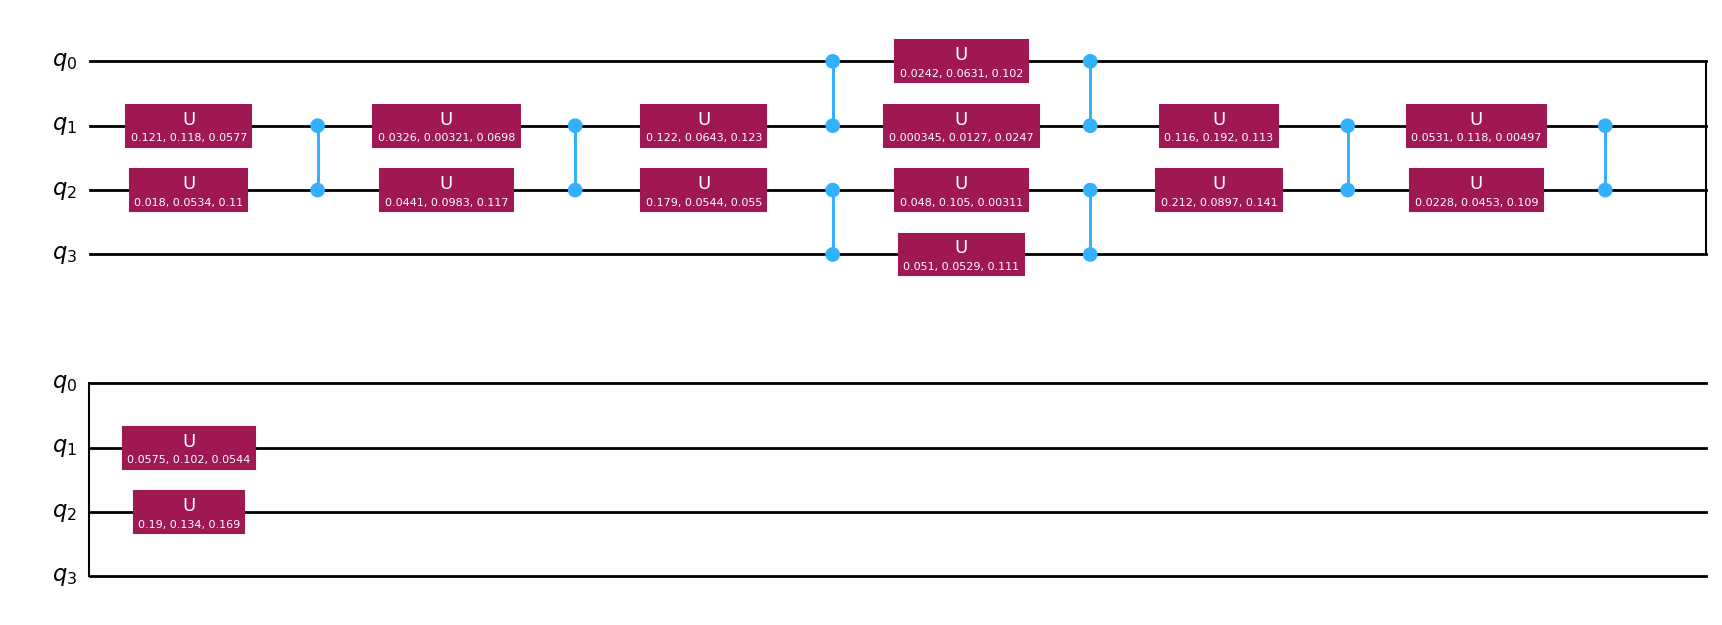

In [351]:
block_n = 3 #block number (for block 2 the following qubits in the original circuit are involved: 1, 2, 3, 4)
#compare the peaked circuit in the above section with the extracted 4-qubit block
qubits_coord = func_gates_coordinates_list(qc)
qc_block_4 = get_block_4_circ(block_n, qc, qubits_coord)
print(get_block_4_list(block_n, n_q, qubits_coord))
qc_block_4.draw('mpl')
#for i in range(len(qc_block)):
#    print(qc_block.data[i])

In [352]:
#Here we plot the circuit with enumerated gates. So, one can check the list of U-gates of the 4-qubit block obtained with get_block_4_list function  
labeled_qc = QuantumCircuit(qc.qubits, qc.clbits)
for idx, (inst, qargs, cargs) in enumerate(qc.data):
    # Clone the instruction and assign a label
    inst_copy = inst.to_mutable()
    inst_copy.label = f"{idx}"
    labeled_qc.append(inst_copy, qargs, cargs)
#labeled_qc.draw('mpl')

In [353]:
# here we find parameters of the reduced block which can replace the 4-qubit block extracted from the circuit
block_n = 0
prec = 0.01
n_tries = 3
qubits_coord = func_gates_coordinates_list(qc)
param_init  = get_block_4_params(block_n, qc, qubits_coord)
qc_block_4 = get_block_4_circ(block_n, qc, qubits_coord)
res_min = find_alt_params_block_4(param_init, prec, n_tries)
new_params = res_min.x
block_devs = res_min.fun
qc_1 = red_block_4_circ(new_params)
#qc_1.draw('mpl')
#block_angles

In [354]:
#simulate the initial extracted full block
simulator = AerSimulator()
qc_block_4.measure_all()
qc_t = transpile(qc_block_4, simulator)
result = simulator.run(qc_t,shots = 1000).result()
counts = result.get_counts(qc_t)
top_10_MPS = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10]
for (k1, v1), (k2, v2) in zip(top_10_MPS, top_10_MPS):
                print(f"{k1} = {v1:<16} | {k2} = {v2}")

0000 = 779              | 0000 = 779
0100 = 116              | 0100 = 116
0010 = 97               | 0010 = 97
1000 = 5                | 1000 = 5
0110 = 3                | 0110 = 3


In [355]:
#simulate the reduced block
simulator = AerSimulator()
qc_1.measure_all()
qc_t = transpile(qc_1, simulator)
result = simulator.run(qc_t,shots = 1000).result()
counts = result.get_counts(qc_t)
top_10_MPS = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10]
for (k1, v1), (k2, v2) in zip(top_10_MPS, top_10_MPS):
                print(f"{k1} = {v1:<16} | {k2} = {v2}")

0000 = 879              | 0000 = 879
0100 = 68               | 0100 = 68
0010 = 47               | 0010 = 47
0110 = 6                | 0110 = 6


In [356]:
block_devs

0.0015253414539597534

## Here we remove the whole 1-st layer of the brick-wall peaked circuit

We replace each block at the beginning of the circuit (n_q/2 blocks) with reduced blocks.

To show where the reduction happens, we keep U-gates, but set angles to 0.

Removing the block at the end of the brick-wall ciruit can be done in the similar way

In [357]:
#Define parameters
prec = 0.0005
n_tries = 3
new_params = []
block_devs = []

qubits_coord = func_gates_coordinates_list(qc)

#Create a copy of initial circuit
circuit_len = len(qc.data)
instructions = []
for instruction, qargs, cargs in qc:
    instructions.append((instruction, qargs, cargs))
mod_instr = []
mod_instr = copy.deepcopy(instructions)

qc_mod = qiskit.QuantumCircuit(n_q)
for i_instr in range(len(mod_instr) - n_q):
        instruction = mod_instr[i_instr][0]
        qarg = mod_instr[i_instr][1] 
        if len(qarg) == 1:
            qc_mod.append(instruction, [mod_instr[i_instr][1][0]._index], [])
        if len(qarg) == 2:
            qc_mod.append(instruction, [mod_instr[i_instr][1][0]._index, mod_instr[i_instr][1][1]._index], [])

number_of_qubits = qc_mod.num_qubits

#Blocks replacement
for i_block in range(0, int(number_of_qubits/2)): #Go over all block at the beginning of the circuit
    block_4_instr_list = get_block_4_list(i_block, number_of_qubits, qubits_coord) # get the list of instructions to be modified
    block_angles  = get_block_4_params(i_block, qc_mod, qubits_coord) # get the parameters of the block for modification
    res_min = find_alt_params_block_4(block_angles, prec, n_tries) #calculate new parameters
    new_params.append(res_min.x)
    block_devs.append(res_min.fun)

    #extract all instructions from circuit and copy them into the new instruction array
    circuit_len = len(qc_mod.data)
    instructions = []
    for instruction, qargs, cargs in qc_mod:
        instructions.append((instruction, qargs, cargs))
    mod_instr = []
    mod_instr = copy.deepcopy(instructions)
    
    #modify all instructions according to modifocations list
    mod_instr[block_4_instr_list[0]][0].params = [0, 0, 0]
    mod_instr[block_4_instr_list[1]][0].params = [0, 0, 0]
    mod_instr[block_4_instr_list[2]][0].params = [0, 0, 0]
    mod_instr[block_4_instr_list[3]][0].params = [0, 0, 0]
    for i_instr in range (12):
        mod_instr[block_4_instr_list[i_instr + 4]][0].params = [new_params[i_block][i_instr * 3 + 0], new_params[i_block][i_instr * 3 + 1], new_params[i_block][i_instr * 3 + 2]]
    
    #create a new circuit and put there modifed instructions
    qc_mod = qiskit.QuantumCircuit(number_of_qubits)
    for i_instr in range(len(mod_instr)):
        instruction = mod_instr[i_instr][0]
        qarg = mod_instr[i_instr][1] 
        if len(qarg) == 1:
            qc_mod.append(instruction, [mod_instr[i_instr][1][0]._index], [])
        if len(qarg) == 2:
            qc_mod.append(instruction, [mod_instr[i_instr][1][0]._index, mod_instr[i_instr][1][1]._index], [])

    
    

In [358]:
#Deviation of each reduced block from initial full block. There are n_q/2 replaced blocks
block_devs

[0.0012140624041150749,
 0.0015126570429600731,
 0.0007191313183450473,
 0.0007767587819901292]

In [359]:
#Showing the resulting circuit with the replced blocks. One can see that initial layer of "bricks" is replaced with identity gates.
labeled_qc = QuantumCircuit(qc.qubits, qc.clbits)
for idx, (inst, qargs, cargs) in enumerate(qc_mod.data):
    # Clone the instruction and assign a label
    inst_copy = inst.to_mutable()
    inst_copy.label = f"{idx}"
    labeled_qc.append(inst_copy, qargs, cargs)
#labeled_qc.draw('mpl')

In [360]:
#simulate the modified circuit
simulator = AerSimulator()
qc_mod_t = transpile(qc_mod, simulator)
qc_mod_t.measure_all()
result = simulator.run(qc_mod_t,shots = 10000).result()
counts_1 = result.get_counts(qc_mod_t)

In [362]:
#Showing how peaked the modified ciruit is after the 1st layer removal
top_10_MPS = sorted(counts_1.items(), key=lambda item: item[1], reverse=True)[:10]
for (k1, v1), (k2, v2) in zip(top_10_MPS, top_10_MPS):
                print(f"{k1} = {v1:<16} | {k2} = {v2}")

00000000 = 9732             | 00000000 = 9732
00000100 = 71               | 00000100 = 71
00001000 = 50               | 00001000 = 50
00000010 = 50               | 00000010 = 50
01000000 = 19               | 01000000 = 19
00010000 = 18               | 00010000 = 18
10000000 = 15               | 10000000 = 15
00000001 = 12               | 00000001 = 12
00001100 = 11               | 00001100 = 11
00000011 = 9                | 00000011 = 9
